In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [3]:
import os
from pathlib import Path

BASE_DIR = '/content/drive/MyDrive/deepfake_detection'
STATS_DIR = os.path.join(BASE_DIR, 'stats')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
PLOTS_DIR = os.path.join(BASE_DIR, 'plots')
REAL_DIR = os.path.join(BASE_DIR, 'real')
FAKE_DIR = os.path.join(BASE_DIR, 'fake')

os.makedirs(STATS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

real_files = sorted(Path(REAL_DIR).glob('*.npy'))
fake_files = sorted(Path(FAKE_DIR).glob('*.npy'))

print(f"Real .npy files found : {len(real_files)}")
print(f"Fake .npy files found : {len(fake_files)}")

Real .npy files found : 1000
Fake .npy files found : 1000


In [4]:
import numpy as np
import json
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import csv
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)
from collections import defaultdict
from pathlib import Path
from dataclasses import dataclass, asdict

In [5]:
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device : {DEVICE}")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU : Tesla T4
Using device : cuda


In [6]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 42


In [21]:
@dataclass
class TemporalCNNConfig:
  model_type : str   = 'TemporalCNN'
  input_size : int   = 2048
  window_size : int   = 5        # smaller window, focusing on differences
  overlap : int   = 0        # no overlap
  num_filters : int   = 32
  kernel_sizes : list  = None     # will be set later
  dropout : float = 0.3
  batch_size : int   = 32
  lr : float = 1e-3
  max_epochs : int   = 50
  es_patience : int   = 5
  lr_patience : int   = 3
  lr_factor : float = 0.5
  seed : int   = 42

  def __post_init__(self):
      if self.kernel_sizes is None:
          self.kernel_sizes = [3]  # multi-scale temporal kernels

cfg = TemporalCNNConfig()

config_path = os.path.join(MODELS_DIR, 'temporal_cnn_config.json')
with open(config_path, 'w') as fp:
    json.dump(asdict(cfg), fp, indent=2, default=str)
print(f"Config saved: {config_path}")
print(f"\nConfig: {asdict(cfg)}")

Config saved: /content/drive/MyDrive/deepfake_detection/models/temporal_cnn_config.json

Config: {'model_type': 'TemporalCNN', 'input_size': 2048, 'window_size': 5, 'overlap': 0, 'num_filters': 32, 'kernel_sizes': [3], 'dropout': 0.3, 'batch_size': 32, 'lr': 0.001, 'max_epochs': 50, 'es_patience': 5, 'lr_patience': 3, 'lr_factor': 0.5, 'seed': 42}


In [22]:
manifest_path = os.path.join(STATS_DIR, 'manifest.json')
with open(manifest_path) as fp:
    manifest = json.load(fp)

# Filter to usable files (>= window_size frames for computing differences)
# With window_size=5, we need at least 5 frames to create 4 differences
manifest = [m for m in manifest if m['n_frames'] >= cfg.window_size]
print(f"Usable files after filtering (>= {cfg.window_size} frames): {len(manifest)}")
print(f"  Real: {sum(1 for m in manifest if m['label']==0)}")
print(f"  Fake: {sum(1 for m in manifest if m['label']==1)}")

Usable files after filtering (>= 5 frames): 1999
  Real: 1000
  Fake: 999


In [23]:
# Use the same train/val/test split as baseline model to ensure fair comparison
split_info_path = os.path.join(STATS_DIR, 'train_val_test_split.json')
with open(split_info_path) as fp:
    split_info = json.load(fp)

train_sources = set(split_info['train_source_ids'])
val_sources   = set(split_info['val_source_ids'])
test_sources  = set(split_info['test_source_ids'])

train_manifest = [m for m in manifest if m['source_id'] in train_sources]
val_manifest   = [m for m in manifest if m['source_id'] in val_sources]
test_manifest  = [m for m in manifest if m['source_id'] in test_sources]

print(f"Train : {len(train_manifest):4d} files  " f"(real={sum(1 for m in train_manifest if m['label']==0)}, " f"fake={sum(1 for m in train_manifest if m['label']==1)})")
print(f"Val   : {len(val_manifest):4d} files  " f"(real={sum(1 for m in val_manifest if m['label']==0)}, " f"fake={sum(1 for m in val_manifest if m['label']==1)})")
print(f"Test  : {len(test_manifest):4d} files  " f"(real={sum(1 for m in test_manifest if m['label']==0)}, " f"fake={sum(1 for m in test_manifest if m['label']==1)})")

Train : 1599 files  (real=800, fake=799)
Val   :  200 files  (real=100, fake=100)
Test  :  200 files  (real=100, fake=100)


In [10]:
class TemporalDifferenceWindowDataset(Dataset):
    def __init__(self, manifest_entries, window_size=5, overlap=0):
      self.window_size = window_size
      self.stride = window_size - overlap
      self.windows = []

      for entry in manifest_entries:
        features = np.load(entry['path']).astype(np.float32)
        n_frames = features.shape[0]
        label = entry['label']
        vid_id = Path(entry['path']).stem

        start = 0
        while start + window_size <= n_frames:
          # Extract window of consecutive frames
          frame_window = features[start : start + window_size]  # shape: (window_size, 2048)

          # Compute differences between consecutive frames
          # This gives us (window_size-1, 2048) differences
          diff_window = np.diff(frame_window, axis=0).astype(np.float32)  # shape: (window_size-1, 2048)

          self.windows.append((diff_window, label, vid_id, start))
          start += self.stride

      print(f"  Dataset created: {len(self.windows)} windows " f"from {len(manifest_entries)} videos")
      print(f"    Window shape (differences): ({window_size-1}, 2048)")

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        window, label, vid_id, start_frame = self.windows[idx]
        # For Conv1d: input should be (channels, sequence_length)
        # We treat spatial features as "channels" and frames as sequence
        # So we transpose: (sequence_length, features) -> (features, sequence_length)
        return (
            torch.tensor(window.T, dtype=torch.float32),  # (2048, window_size-1)
            torch.tensor(label, dtype=torch.float32),
        )

print("Building train dataset...")
train_dataset = TemporalDifferenceWindowDataset(train_manifest, cfg.window_size, cfg.overlap)

print("Building val dataset...")
val_dataset = TemporalDifferenceWindowDataset(val_manifest, cfg.window_size, cfg.overlap)

print("Building test dataset (not used during training)...")
test_dataset = TemporalDifferenceWindowDataset(test_manifest, cfg.window_size, cfg.overlap)

Building train dataset...
  Dataset created: 58732 windows from 1599 videos
    Window shape (differences): (4, 2048)
Building val dataset...
  Dataset created: 7652 windows from 200 videos
    Window shape (differences): (4, 2048)
Building test dataset (not used during training)...
  Dataset created: 7593 windows from 200 videos
    Window shape (differences): (4, 2048)


In [11]:
train_loader = DataLoader(
  train_dataset,
  batch_size=cfg.batch_size,
  shuffle=True,
  num_workers=2,
  pin_memory=True,
)

val_loader = DataLoader(
  val_dataset,
  batch_size=cfg.batch_size,
  shuffle=False,
  num_workers=2,
  pin_memory=True,
)

test_loader = DataLoader(
  test_dataset,
  batch_size=cfg.batch_size,
  shuffle=False,
  num_workers=2,
  pin_memory=True,
)

print(f"Train loader : {len(train_loader)} batches")
print(f"Val   loader : {len(val_loader)} batches")
print(f"Test  loader : {len(test_loader)} batches  (not used in training)")

Train loader : 1836 batches
Val   loader : 240 batches
Test  loader : 238 batches  (not used in training)


In [24]:
class TemporalCNNDetector(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Multi-scale convolution branches
        self.conv_branches = nn.ModuleList()
        for kernel_size in cfg.kernel_sizes:
            branch = nn.Sequential(
                nn.Conv1d(
                    in_channels=cfg.input_size,
                    out_channels=cfg.num_filters,
                    kernel_size=kernel_size,
                    stride=1,
                    padding='same'
                ),
                nn.ReLU(),
                nn.BatchNorm1d(cfg.num_filters),
                nn.AdaptiveAvgPool1d(1),  # Global average pooling
            )
            self.conv_branches.append(branch)

        # Fully connected layers after concatenating multi-scale features
        num_branches = len(cfg.kernel_sizes)
        fc_input_size = cfg.num_filters * num_branches

        self.classifier = nn.Sequential(
            nn.Dropout(cfg.dropout),
            nn.Linear(fc_input_size, 128),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        # x shape: (batch, input_size, seq_len)
        branch_outputs = []
        for branch in self.conv_branches:
            out = branch(x)  # (batch, num_filters, 1)
            out = out.squeeze(-1)  # (batch, num_filters)
            branch_outputs.append(out)

        # Concatenate multi-scale features
        combined = torch.cat(branch_outputs, dim=1)  # (batch, num_filters * num_branches)
        logit = self.classifier(combined)  # (batch, 1)
        return logit.squeeze(1)  # (batch,)

model = TemporalCNNDetector(cfg).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {model}")
print(f"\nTrainable parameters: {total_params:,}")

Model: TemporalCNNDetector(
  (conv_branches): ModuleList(
    (0): Sequential(
      (0): Conv1d(2048, 32, kernel_size=(3,), stride=(1,), padding=same)
      (1): ReLU()
      (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): AdaptiveAvgPool1d(output_size=1)
    )
  )
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=32, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

Trainable parameters: 201,057


In [25]:
criterion = nn.BCEWithLogitsLoss()

optimizer = Adam(model.parameters(), lr=cfg.lr)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=cfg.lr_factor,
    patience=cfg.lr_patience,
)

print("Optimizer and scheduler initialized")

Optimizer and scheduler initialized


In [26]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for windows, labels in loader:
        windows = windows.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(windows)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(labels)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += len(labels)

    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for windows, labels in loader:
            windows = windows.to(device)
            labels = labels.to(device)

            logits = model(windows)
            loss = criterion(logits, labels)

            total_loss += loss.item() * len(labels)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += len(labels)

    return total_loss / total, correct / total

In [27]:
# Training loop with early stopping
print(f"  Starting Temporal CNN training up to {cfg.max_epochs} epochs")
print(f"  Early stopping patience: {cfg.es_patience} epochs")
print()

smooth_window = 3
new_es_patience = 5

log_rows = []
val_loss_history = []

best_val_loss = float('inf')
epochs_no_improve = 0
best_epoch = 0
best_val_acc = 0

for epoch in range(1, cfg.max_epochs + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion, DEVICE)

    current_lr = optimizer.param_groups[0]['lr']

    val_loss_history.append(val_loss)
    smoothed_val_loss = float(np.mean(val_loss_history[-smooth_window:]))
    scheduler.step(smoothed_val_loss)

    row = {
        'epoch': epoch,
        'train_loss': round(train_loss, 5),
        'val_loss': round(val_loss, 5),
        'smoothed_val_loss': round(smoothed_val_loss, 5),
        'train_acc': round(train_acc, 5),
        'val_acc': round(val_acc, 5),
        'lr': current_lr,
    }
    log_rows.append(row)

    print(f"Epoch {epoch:03d} | " f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | " f"val_loss={val_loss:.4f} (smooth={smoothed_val_loss:.4f}) val_acc={val_acc:.4f} | " f"lr={current_lr:.2e}")

    # save best checkpoint
    if smoothed_val_loss < best_val_loss:
        best_val_loss = smoothed_val_loss
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(MODELS_DIR, 'temporal_cnn_best.pt'))
        print(f"New best val_acc= {best_val_acc:.4f} saved temporal_cnn_best.pt")

    # early stopping
    if epochs_no_improve >= new_es_patience:
        print(f"\nEarly stopping at epoch {epoch} " f"(no val improvement for {new_es_patience} epochs).")
        break

# save final checkpoint
torch.save(model.state_dict(), os.path.join(MODELS_DIR, 'temporal_cnn_final.pt'))
print(f"\nFinal checkpoint saved: temporal_cnn_final.pt")
print(f"Best checkpoint  saved: temporal_cnn_best.pt  (epoch {best_epoch}, " f"val_loss={best_val_loss:.4f})")

  Starting Temporal CNN training up to 50 epochs
  Early stopping patience: 5 epochs

Epoch 001 | train_loss=0.6589  train_acc=0.6001 | val_loss=0.6103 (smooth=0.6103) val_acc=0.6678 | lr=1.00e-03
New best val_acc= 0.6678 saved temporal_cnn_best.pt
Epoch 002 | train_loss=0.5975  train_acc=0.6769 | val_loss=0.5800 (smooth=0.5951) val_acc=0.6922 | lr=1.00e-03
New best val_acc= 0.6922 saved temporal_cnn_best.pt
Epoch 003 | train_loss=0.5531  train_acc=0.7155 | val_loss=0.5772 (smooth=0.5891) val_acc=0.6924 | lr=1.00e-03
New best val_acc= 0.6924 saved temporal_cnn_best.pt
Epoch 004 | train_loss=0.5147  train_acc=0.7452 | val_loss=0.5651 (smooth=0.5741) val_acc=0.7035 | lr=1.00e-03
New best val_acc= 0.7035 saved temporal_cnn_best.pt
Epoch 005 | train_loss=0.4853  train_acc=0.7642 | val_loss=0.5644 (smooth=0.5689) val_acc=0.7092 | lr=1.00e-03
New best val_acc= 0.7092 saved temporal_cnn_best.pt
Epoch 006 | train_loss=0.4571  train_acc=0.7834 | val_loss=0.5668 (smooth=0.5654) val_acc=0.7105 | 

Training log saved: /content/drive/MyDrive/deepfake_detection/models/temporal_cnn_training_log.csv


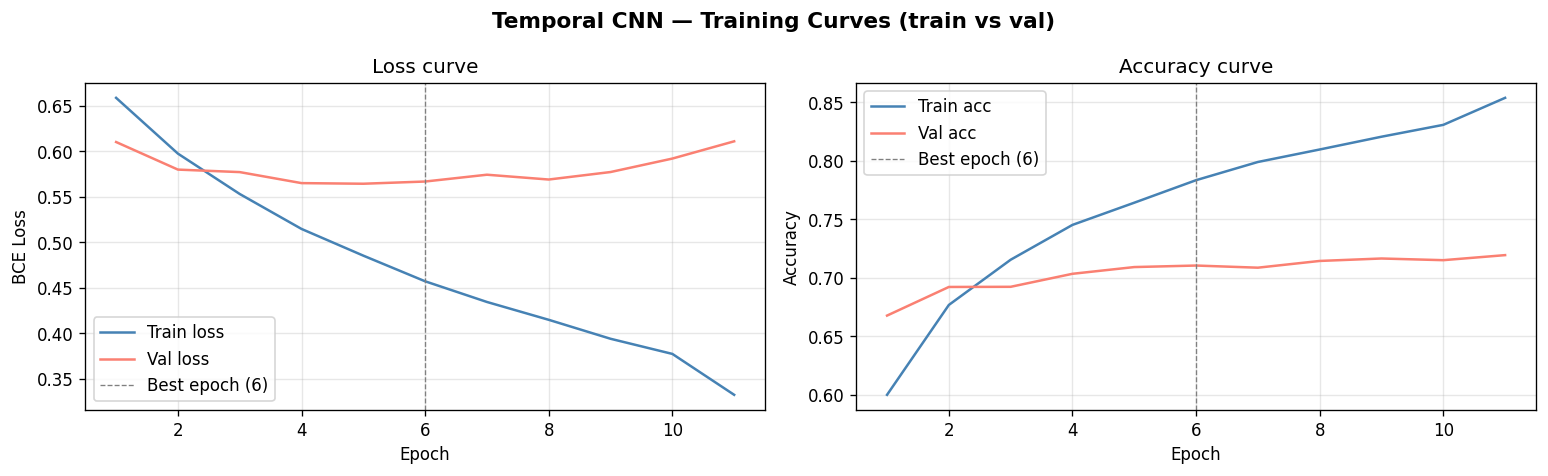

Saved: /content/drive/MyDrive/deepfake_detection/plots/temporal_cnn_training_curves.png

TEMPORAL CNN TRAINING SUMMARY

  Total epochs run    : 11
  Best epoch          : 6
  Best val loss       : 0.56543
  Best val accuracy   : 0.7194  (71.94%)
  Final train accuracy: 0.8537  (85.37%)


In [28]:
log_path = os.path.join(MODELS_DIR, 'temporal_cnn_training_log.csv')
with open(log_path, 'w', newline='') as fp:
    writer = csv.DictWriter(fp, fieldnames=log_rows[0].keys())
    writer.writeheader()
    writer.writerows(log_rows)
print(f"Training log saved: {log_path}")

epochs_ran = [r['epoch'] for r in log_rows]
t_loss = [r['train_loss'] for r in log_rows]
v_loss = [r['val_loss'] for r in log_rows]
t_acc = [r['train_acc'] for r in log_rows]
v_acc = [r['val_acc'] for r in log_rows]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_ran, t_loss, label='Train loss', color='steelblue')
axes[0].plot(epochs_ran, v_loss, label='Val loss', color='salmon')
axes[0].axvline(best_epoch, linestyle='--', color='gray', linewidth=0.8, label=f'Best epoch ({best_epoch})')
axes[0].set_title('Loss curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, t_acc, label='Train acc', color='steelblue')
axes[1].plot(epochs_ran, v_acc, label='Val acc', color='salmon')
axes[1].axvline(best_epoch, linestyle='--', color='gray', linewidth=0.8, label=f'Best epoch ({best_epoch})')
axes[1].set_title('Accuracy curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Temporal CNN — Training Curves (train vs val)', fontsize=13, fontweight='bold')
plt.tight_layout()
curve_path = os.path.join(PLOTS_DIR, 'temporal_cnn_training_curves.png')
plt.savefig(curve_path, bbox_inches='tight')
plt.show()
print(f"Saved: {curve_path}")

print()
print("TEMPORAL CNN TRAINING SUMMARY")
print()
print(f"  Total epochs run    : {len(log_rows)}")
print(f"  Best epoch          : {best_epoch}")
print(f"  Best val loss       : {best_val_loss:.5f}")
print(f"  Best val accuracy   : {max(v_acc):.4f}  ({max(v_acc)*100:.2f}%)")
print(f"  Final train accuracy: {t_acc[-1]:.4f}  ({t_acc[-1]*100:.2f}%)")

In [29]:
# Loading the best checkpoint chosen by val acc
model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, 'temporal_cnn_best.pt'), map_location=DEVICE)
)
model.eval()
print(f"Loaded temporal_cnn_best.pt (best val checkpoint from epoch {best_epoch})")
print("Running inference on held-out test set...")

# Collecting window-level predictions
test_window_probs = []
test_window_labels = []
test_window_vid_ids = []
test_window_starts = []

with torch.no_grad():
    for entry in test_manifest:
        features = np.load(entry['path']).astype(np.float32)
        n_frames = features.shape[0]
        vid_id = Path(entry['path']).stem
        stride = cfg.window_size - cfg.overlap

        start = 0
        while start + cfg.window_size <= n_frames:
            # Extract window and compute differences
            frame_window = features[start : start + cfg.window_size]
            diff_window = np.diff(frame_window, axis=0).astype(np.float32)

            # Convert to tensor and run inference
            x = torch.tensor(diff_window.T, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            prob = torch.sigmoid(model(x)).item()
            test_window_probs.append(prob)
            test_window_labels.append(entry['label'])
            test_window_vid_ids.append(vid_id)
            test_window_starts.append(start)

            start += stride

print(f"Total test windows evaluated: {len(test_window_probs)}")

Loaded temporal_cnn_best.pt (best val checkpoint from epoch 6)
Running inference on held-out test set...
Total test windows evaluated: 7593


In [30]:
# Aggregate window probabilities to video level using confidence-weighted pooling
video_data = defaultdict(lambda: {'probs': [], 'label': None})

for prob, label, vid_id in zip(test_window_probs, test_window_labels, test_window_vid_ids):
    video_data[vid_id]['probs'].append(prob)
    video_data[vid_id]['label'] = int(label)

y_true = []
y_probs = []

for vid_id, data in video_data.items():
    probs_arr = np.array(data['probs'])
    y_probs.append(np.mean(probs_arr))
    y_true.append(data['label'])

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = (y_probs >= 0.5).astype(int)

# Computing metrics
tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
fpr_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0

print("  TEMPORAL CNN EVALUATION SUMMARY")
print()
print(f"  Aggregation : Confidence-Weighted Mean (video level)")
print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}   ({accuracy_score(y_true, y_pred)*100:.2f}%)")
print(f"  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  Recall : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  F1 score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  AUC-ROC : {roc_auc_score(y_true, y_probs):.4f}")
print(f"  AUC-PR : {average_precision_score(y_true, y_probs):.4f}")
print(f"  FPR : {fpr_rate:.4f}  (real videos flagged as fake)")
print(f"  FNR : {fnr_rate:.4f}  (fake videos missed)")
print(f"  TP/TN/FP/FN : {tp} / {tn} / {fp} / {fn}")
print()
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

  TEMPORAL CNN EVALUATION SUMMARY

  Aggregation : Confidence-Weighted Mean (video level)
  Accuracy : 0.9000   (90.00%)
  Precision : 0.8774
  Recall : 0.9300
  F1 score : 0.9029
  AUC-ROC : 0.9374
  AUC-PR : 0.9381
  FPR : 0.1300  (real videos flagged as fake)
  FNR : 0.0700  (fake videos missed)
  TP/TN/FP/FN : 93 / 87 / 13 / 7

              precision    recall  f1-score   support

        Real       0.93      0.87      0.90       100
        Fake       0.88      0.93      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



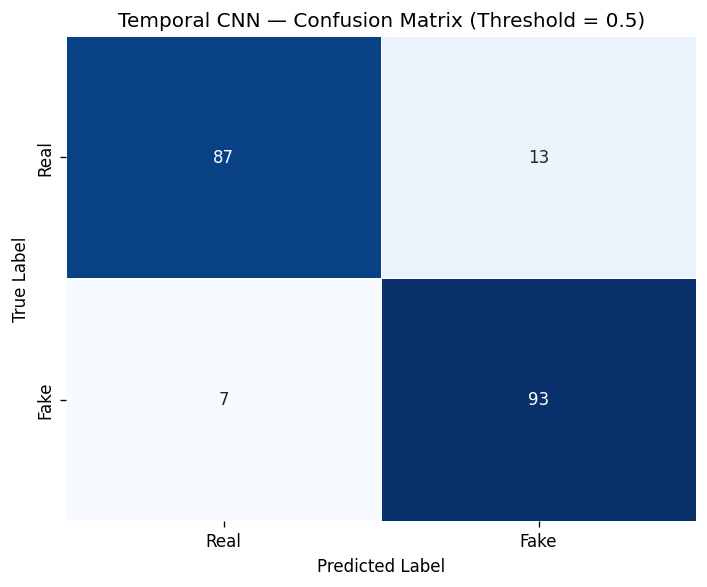

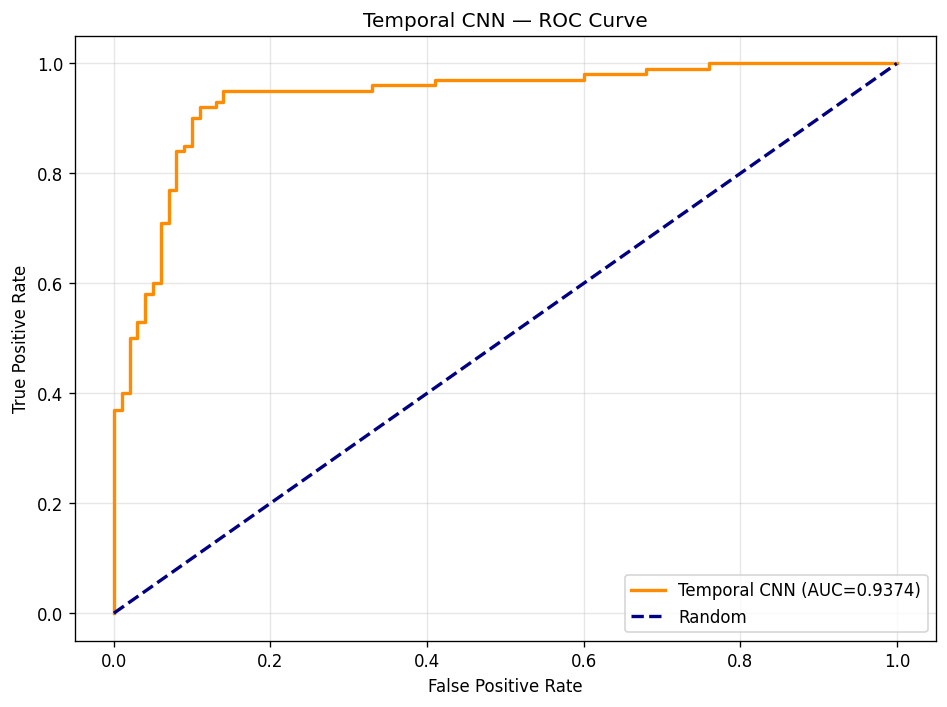

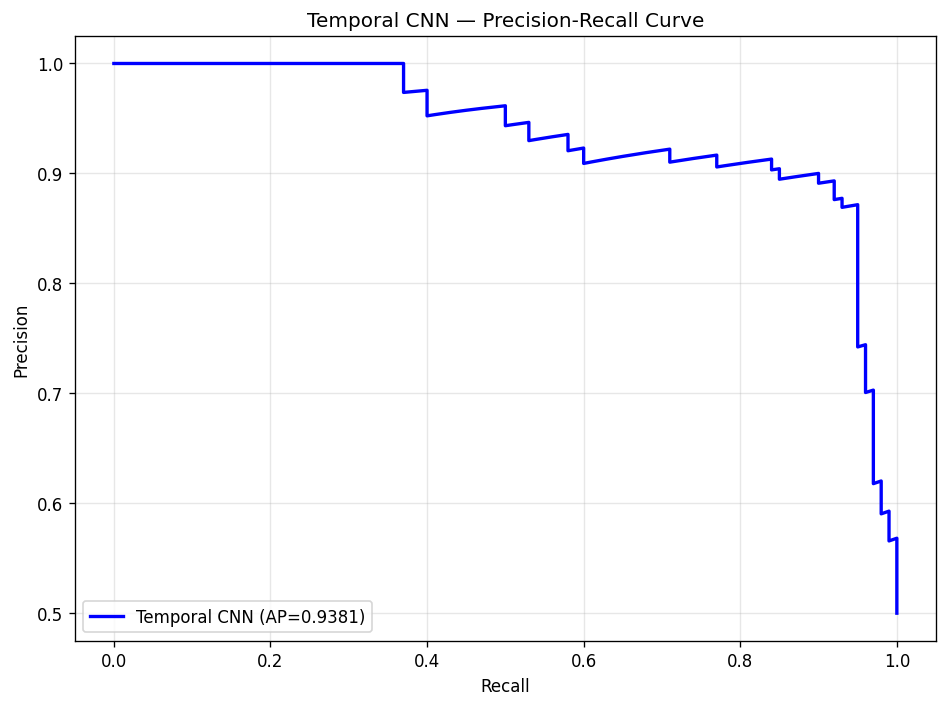

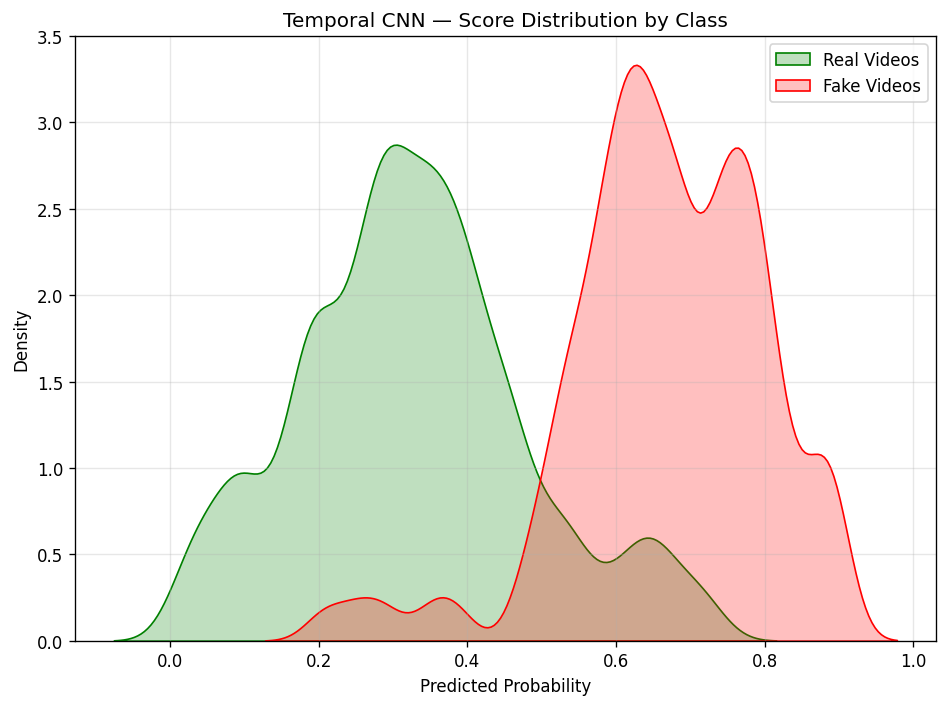

All evaluation plots saved.


In [31]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            linewidths=0.5, cbar=False)
plt.title('Temporal CNN — Confusion Matrix (Threshold = 0.5)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'temporal_cnn_confusion_matrix.png'), bbox_inches='tight')
plt.show()

# AUC-ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Temporal CNN (AUC={roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Temporal CNN — ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'temporal_cnn_roc_curve.png'), bbox_inches='tight')
plt.show()

# Precision-Recall Curve
plt.figure(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_true, y_probs)
ap = average_precision_score(y_true, y_probs)
plt.plot(recall, precision, color='blue', lw=2, label=f'Temporal CNN (AP={ap:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Temporal CNN — Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'temporal_cnn_pr_curve.png'), bbox_inches='tight')
plt.show()

# Score Distribution
plt.figure(figsize=(8, 6))
real_probs = y_probs[y_true == 0]
fake_probs = y_probs[y_true == 1]
sns.kdeplot(real_probs, bw_adjust=0.5, fill=True, label='Real Videos', color='green')
sns.kdeplot(fake_probs, bw_adjust=0.5, fill=True, label='Fake Videos', color='red')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.title('Temporal CNN — Score Distribution by Class')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'temporal_cnn_score_distribution.png'), bbox_inches='tight')
plt.show()

print("All evaluation plots saved.")